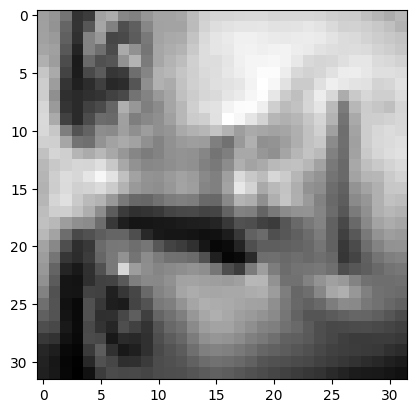

In [2]:
import numpy as np
from scipy.io import loadmat
results=loadmat('yalefaces.mat')
X=results['X']

# print an image of the matrix
import matplotlib.pyplot as plt
plt.imshow(X[:,5].reshape(32,32).T, cmap='gray')
plt.show()

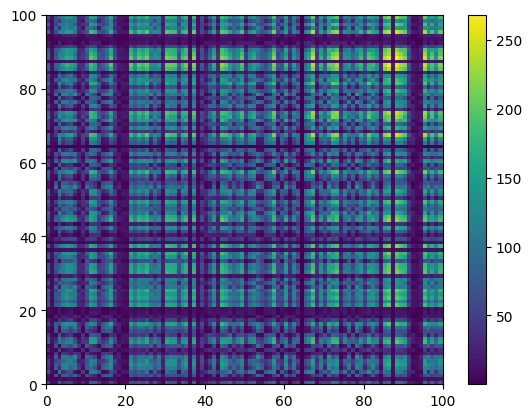

In [ ]:
#  Compute a 100×100 correlation matrix C where you will compute the dot product (correlation)
# between the first 100 images in the matrix X. Thus each element is given by cjk = xT
# jxk where xj is
# the jth column of the matrix. Plot the correlation matrix using pcolor.

C=np.zeros((100,100))
for j in range(100):
    for k in range(100):
        # could have used np.dot(X[:,j],X[:,k]) as well
        C[j,k]=X[:,j].T @ X[:,k]
plt.pcolor(C)
plt.colorbar()
plt.show()

# Why do we use the dot product to compute the correlation between two images? The dot product measures the similarity between two vectors (in this case, the pixel values of the images). 
# If the dot product is high, it indicates that the images are similar in terms of their pixel intensity patterns. T
# his is because the dot product sums the products of corresponding pixel values, which will be larger when the images have similar features and patterns.

Most correlated images: (np.int64(88), np.int64(88))
Most uncorrelated images: (np.int64(64), np.int64(64))


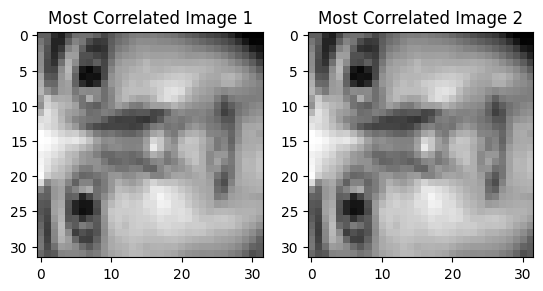

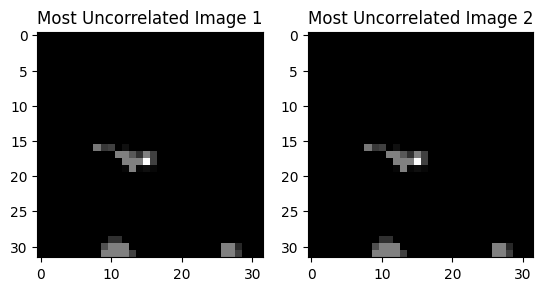

In [ ]:
# From the correlation matrix for part (a), which two images are most highly correlated? Which
# are most uncorrelated? Plot these faces.

# Find the indices of the most highly correlated images
# by flattening the correlation matrix and finding the index of the maximum value - very simple
most_correlated = np.unravel_index(np.argmax(C, axis=None), C.shape)
print("Most correlated images:", most_correlated)

# Same idea but now we want the minimum value for the most uncorrelated images
most_uncorrelated = np.unravel_index(np.argmin(C, axis=None), C.shape)
print("Most uncorrelated images:", most_uncorrelated)

# Plot the most correlated images
plt.subplot(1, 2, 1)
plt.imshow(X[:, most_correlated[0]].reshape(32, 32).T, cmap='gray')
plt.title("Most Correlated Image 1")
plt.subplot(1, 2, 2)
plt.imshow(X[:, most_correlated[1]].reshape(32, 32).T, cmap='gray')
plt.title("Most Correlated Image 2")
plt.show()

# Plot the most uncorrelated images
plt.subplot(1, 2, 1)
plt.imshow(X[:, most_uncorrelated[0]].reshape(32, 32).T, cmap='gray')
plt.title("Most Uncorrelated Image 1")
plt.subplot(1, 2, 2)
plt.imshow(X[:, most_uncorrelated[1]].reshape(32, 32).T, cmap='gray')
plt.title("Most Uncorrelated Image 2")
plt.show()

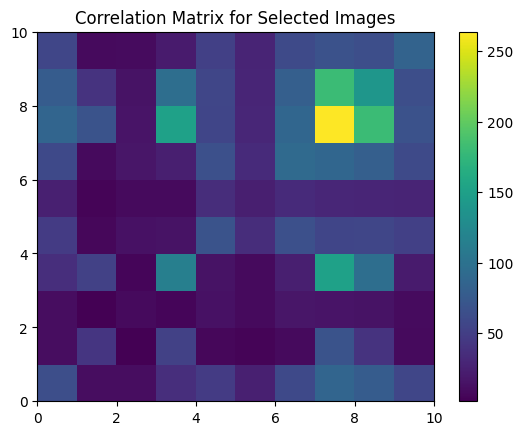

In [ ]:
# Repeat part (a) but now compute the 10 ×10 correlation matrix between images and plot the
# correlation matrix between them.
# [1,313,512,5,2400,113,1024,87,314,2005].
# (Just for clarification, the first image is labeled as one, not zero like python might do)
indices = [1, 313, 512, 5, 2400, 113, 1024, 87, 314, 2005]
C_subset = np.zeros((10, 10))
for j in range(10):
    for k in range(10):
        # same as before but now we are using the specified indices to compute the correlation matrix for the selected images
        C_subset[j, k] = X[:, indices[j] - 1].T @ X[:, indices[k] - 1]
plt.pcolor(C_subset)
plt.colorbar()
plt.title("Correlation Matrix for Selected Images")
plt.show()

In [12]:
# Create the matrix Y = XXT and find the first six eigenvectors with the largest magnitude eigenvalue.
Y = X @ X.T
U, S, Vt = np.linalg.svd(X, full_matrices=False)
# Sort the singular values in descending order and get the indices
sorted_indices = np.argsort(S)[::-1]
# Select the first six left singular vectors corresponding to the largest singular values
top_six_eigenvectors = U[:, sorted_indices[:6]]

print("Top six eigenvectors (principal components):")
print(top_six_eigenvectors)

Top six eigenvectors (principal components):
[[-0.02384327 -0.04535378 -0.05653196  0.04441826 -0.03378603  0.02207542]
 [-0.02576146 -0.04567536 -0.04709124  0.05057969 -0.01791442  0.03378819]
 [-0.02728448 -0.04474528 -0.0362807   0.05522219 -0.00462854  0.04487476]
 ...
 [-0.02082937  0.03737158 -0.06455006 -0.01006919  0.06172201  0.03025485]
 [-0.0193902   0.03557383 -0.06196898 -0.00355905  0.05796353  0.02850199]
 [-0.0166019   0.02965746 -0.05241684  0.00040934  0.05757412  0.00941028]]


In [13]:
# Compare the first eigenvector v1 from (d) with the first SVD mode u1 from past exercise and compute the
# norm of difference of their absolute values.

v1 = top_six_eigenvectors[:, 0]
u1 = U[:, 0]
difference_norm = np.linalg.norm(np.abs(v1) - np.abs(u1))
print("Norm of the difference between the absolute values of v1 and u1:", difference_norm)

Norm of the difference between the absolute values of v1 and u1: 0.0


In [ ]:
# Compute the percentage of variance captured by each of the first 6 SVD modes. Plot the first 6
# SVD mode
variance_captured = (S[sorted_indices[:6]] ** 2) / np.sum(S ** 2) * 100
print("Percentage of variance captured by the first 6 SVD modes:", variance_captured)